In [1]:
import pandas as pd
import numpy as np

In [2]:
# Code to create data for this question 
num = 100000 
 
difficulty = np.random.uniform(0, 1, (num,)) 
 
speed = np.maximum(np.random.normal(15, 5, (num, )) - difficulty * 10, 0) 
 
accident = np.minimum(np.maximum(0.03 * speed + 0.4 * difficulty + np.random.normal(0, 0.3, (num,)), 0), 1) 
 
df = pd.DataFrame({'difficulty': difficulty, 'speed': speed, 'accident': accident}) 

In [3]:
df

,difficulty,speed,accident
0,0.539928,6.155424,0.290462
1,0.863072,5.995418,0.614630
2,0.123453,14.081844,0.708904
3,0.672014,8.263601,0.560144
4,0.993389,0.000000,0.288653
...,...,...,...
99995,0.692920,8.307581,0.426850
99996,0.139557,12.912379,0.107647
99997,0.182096,19.041877,0.048962
99998,0.511274,17.840678,0.655233


In this example, `Z` = the likelihood of a biking accident, `Y` = speed, and `X` = trail difficulty.

We assume that `X` decreases `Y` causally because people decrease their speed on difficult trails. 

In addition, `Y` and `X` both increase `Z` causally because fast biking on difficult trails leads to accidents. 

Difficulty will be on a scale from 0 to 1, speed in miles per hour, and likelihood of an accident also on a scale from 0 to 1. (Based on the numbers, I'd say these trails are quite challenging!) 

Question 1
Use `X` to predict `Y` many times via regression with different data sets. Use many samples in each prediction. Which is closest to the average coefficient of `X` if you do the experiment enough times? 

A -10.14

B -9.243

C -9.661

D -8.927

In [4]:
from sklearn.linear_model import LinearRegression

In [5]:
coefs = []
for i in range(100):
    sample = df.sample(50_000) # Use half of dataset
    X = sample[['difficulty']]
    y = sample['speed']
    model = LinearRegression()
    model.fit(X,y)
    # print(model.coef_)
    coefs.append(model.coef_[0])
np.mean(coefs)    

np.float64(-9.635991155636434)

A1. C

Question 2 Then use `X` and `Z` to predict `Y` many times via regression with different datasets. Which of these is closest to the average coefficient of `X`?

A -11.23

B -10.85

C -10.33

D -9.821


In [6]:
coefs = []
for i in range(100):
    sample = df.sample(50_000) # Use half of dataset
    X = sample[['difficulty', 'accident']]
    y = sample['speed']
    model = LinearRegression()
    model.fit(X,y)
    # print(model.coef_)
    coefs.append(model.coef_[0])
np.mean(coefs)    

np.float64(-10.316874872155989)

A2. C

Reflection Problem 3

In [ ]:
num = 1_000

# Simulate the lightning storm which has the first effects caused by it. We could model it as a 
# float (0 == no storm and from there it is a severity of a storm). 
# This seemed complicated so I make it binary instead (Yes or No storm) with equal prob
lightning_storm = np.random.binomial(1, 0.5, num)

# Lightning storms frighten bears, decreasing their population
# Create baseline population noise
bears = np.random.normal(1_000, 50, num) # Normal distribution centered around 1,000 with std 50
# Add effect of lighting storm = 1
bears = np.where(lightning_storm == 1, bears * 0.9, bears) # When lightning storm happens it decreases bears population by 10%

# Lightning storm frighten deer, decreasing their population
deer = np.random.normal(1_000, 50, num) # Normal distribution centered around 1,000 with std 50
deer = np.where(lightning_storm == 1, deer * 0.9, deer) # When lightning storm happens it decreases deer population by 10%

# Lightning storm cause flowers to grow, increasing their population.
flowers = np.random.normal(1_000, 50, num) # Normal distribution centered around 1,000 with std 50
flowers = np.where(lightning_storm == 1, flowers + 100, flowers) # When lightning storm happens it decreases deer by 100 (static value)

# Bears eat deer, decreasing their population.
deer = deer - (bears * 0.1) # Decrease deer count by 10% of the bear population. (random number I decided on shows effect)

# Deer eat flowers, decreasing their population.
flowers = flowers - (deer * 0.1) # Decrease flowers count by 10% of the deer population. (random number I decided on)

result = pd.DataFrame(
    {
        'lightning_storm': lightning_storm,
        'bears': bears,
        'deer': deer,
        'flowers': flowers
    }
)
result

,lightning_storm,bears,deer,flowers
0,0,953.132296,927.109641,891.119873
1,0,946.427791,910.264971,907.112609
2,1,836.272904,884.352347,1008.219693
3,0,1013.473812,867.323371,936.033293
4,0,927.655727,968.379388,810.677800
...,...,...,...,...
995,0,1017.711888,822.841630,938.744167
996,0,986.005437,874.847080,948.459057
997,0,955.664679,949.841479,914.585134
998,1,939.753974,761.176728,1029.279310


In [19]:
import matplotlib.pyplot as plt

(array([ 14.,  64., 164., 191., 185., 172., 130.,  60.,  17.,   3.]),
 array([ 779.76243017,  818.72484735,  857.68726453,  896.64968171,
         935.6120989 ,  974.57451608, 1013.53693326, 1052.49935044,
        1091.46176762, 1130.4241848 , 1169.38660198]),
 <BarContainer object of 10 artists>)

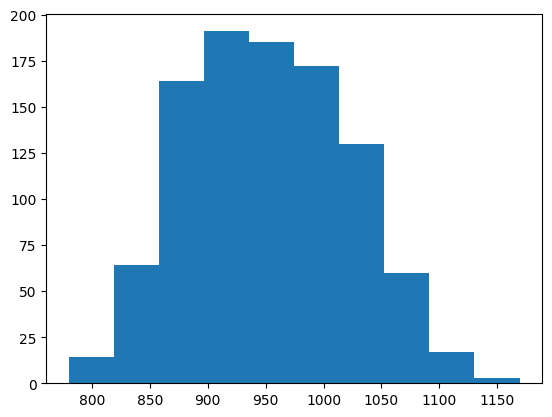

In [37]:
plt.hist(bears)

(array([  8.,  48., 158., 218., 221., 203., 106.,  31.,   5.,   2.]),
 array([ 672.86557454,  715.34374908,  757.82192362,  800.30009816,
         842.7782727 ,  885.25644724,  927.73462178,  970.21279632,
        1012.69097086, 1055.1691454 , 1097.64731994]),
 <BarContainer object of 10 artists>)

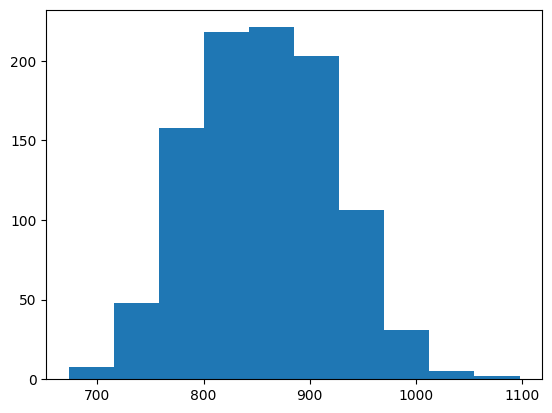

In [38]:
plt.hist(deer)

(array([520.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 480.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

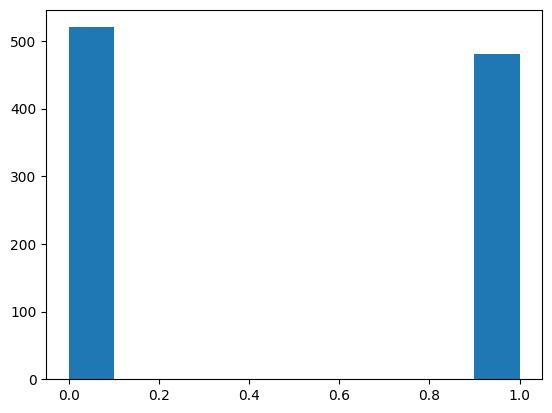

In [39]:
plt.hist(lightning_storm)

(array([  2.,  22.,  77., 155., 218., 194., 191., 100.,  34.,   7.]),
 array([ 733.6589316 ,  778.07432155,  822.48971151,  866.90510147,
         911.32049143,  955.73588138, 1000.15127134, 1044.5666613 ,
        1088.98205125, 1133.39744121, 1177.81283117]),
 <BarContainer object of 10 artists>)

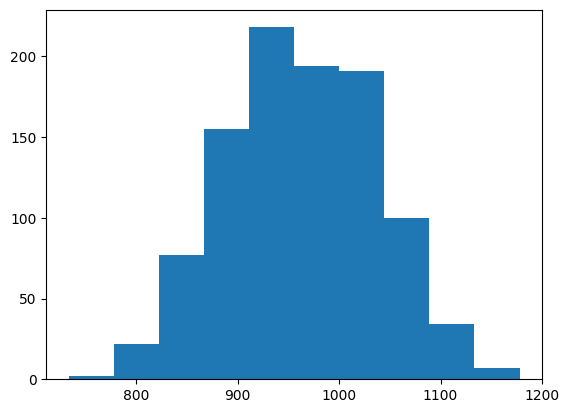

In [40]:
plt.hist(flowers)